# 05 — Visualize driver circuit specialization

## Purpose

Create a consistent, publication-quality visual system for driver specialization, versatility, circuit fingerprints, model residuals, and circuit similarity.

The charts describe model patterns without treating versatility as overall quality or overtaking-environment specialization as direct pass-making skill.

## Inputs

- `data/outputs/driver_specialization_scores.csv`
- `data/outputs/driver_track_model_results.csv`
- `data/processed/driver_race_with_circuit_features.csv`

All charts use saved outputs from validated upstream notebooks. No models are refitted here.

## Outputs

- Six publication-quality PNG figures in `README assets/`
- `data/outputs/notebook_05_validation_report.json`

## Imports

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from PIL import Image as PILImage
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import pdist, squareform

## Configuration

In [2]:
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"
ASSET_DIR = PROJECT_ROOT / "README assets"

INPUT_PATHS = {
    "specialization": OUTPUT_DIR / "driver_specialization_scores.csv",
    "track_results": OUTPUT_DIR / "driver_track_model_results.csv",
    "circuit_features": PROCESSED_DIR / "driver_race_with_circuit_features.csv",
}
FIGURE_PATHS = {
    "driver_specialists": ASSET_DIR / "01_driver_specialists.png",
    "driver_heatmap": ASSET_DIR / "02_driver_specialization_heatmap.png",
    "versatility_scatter": ASSET_DIR / "03_versatility_vs_outperformance.png",
    "circuit_fingerprints": ASSET_DIR / "04_circuit_fingerprints.png",
    "residual_status": ASSET_DIR / "05_residuals_by_finish_status.png",
    "circuit_similarity": ASSET_DIR / "06_circuit_similarity.png",
}
VALIDATION_REPORT_PATH = OUTPUT_DIR / "notebook_05_validation_report.json"

TRAITS = ("speed", "technical", "downforce", "overtaking")
SLOPE_COLUMNS = [f"{trait}_slope" for trait in TRAITS]
ZSCORE_COLUMNS = [f"{trait}_zscore" for trait in TRAITS]
TRAIT_LABELS = {
    "speed": "Speed",
    "technical": "Technical",
    "downforce": "Downforce",
    "overtaking": "Overtaking environment",
}
LOW_LABELS = {
    "speed": "Low-speed",
    "technical": "Low-technical",
    "downforce": "Low-downforce",
    "overtaking": "Overtaking-difficult",
}
HIGH_LABELS = {
    "speed": "High-speed",
    "technical": "High-technical",
    "downforce": "High-downforce",
    "overtaking": "Overtaking-friendly",
}

COLOR_HIGH = "#D55E00"
COLOR_LOW = "#0072B2"
COLOR_NEUTRAL = "#6B7280"
COLOR_DARK = "#202124"
COLOR_GRID = "#D7DCE2"
COLOR_ACCENT = "#B91C1C"
COLOR_MEAN = "#111827"
FIGURE_DPI = 220
MIN_IMAGE_WIDTH = 1800
MIN_IMAGE_HEIGHT = 1000

ASSET_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": COLOR_DARK,
        "axes.labelcolor": COLOR_DARK,
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.color": COLOR_DARK,
        "ytick.color": COLOR_DARK,
        "text.color": COLOR_DARK,
        "font.family": "DejaVu Sans",
        "savefig.facecolor": "white",
    }
)

## Helper functions

In [3]:
def require_files(paths: Mapping[str, Path]) -> None:
    """Raise a readable error when a required input is absent."""
    missing = [str(path) for path in paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing validated upstream outputs: {missing}")


def save_figure(figure: plt.Figure, path: Path) -> None:
    """Save one publication-quality PNG and close its Matplotlib figure."""
    figure.savefig(
        path,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.close(figure)


def report_check(name: str, passed: bool, details: Any) -> Dict[str, Any]:
    """Create a JSON-serializable validation record."""
    return {"check": name, "passed": bool(passed), "details": details}


def annotate_horizontal_bars(
    axis: plt.Axes,
    values: Sequence[float],
) -> None:
    """Label horizontal bars in percentage-point units."""
    span = max(max(abs(value) for value in values), 0.01)
    padding = span * 0.035
    for index, value in enumerate(values):
        alignment = "left" if value >= 0 else "right"
        x_position = value + padding if value >= 0 else value - padding
        axis.text(
            x_position,
            index,
            f"{value:+.2f}",
            va="center",
            ha=alignment,
            fontsize=8,
            color=COLOR_DARK,
        )


def display_saved_figure(path: Path) -> None:
    """Display a saved figure when running inside a notebook."""
    display(Image(filename=str(path)))

## Processing

In [4]:
require_files(INPUT_PATHS)

specialization = pd.read_csv(INPUT_PATHS["specialization"])
track_results = pd.read_csv(INPUT_PATHS["track_results"])
circuit_rows = pd.read_csv(INPUT_PATHS["circuit_features"])
circuit_features = (
    circuit_rows[
        [
            "circuit_id", "circuit_name", "primary_trait",
            "speed_zscore", "technical_zscore",
            "downforce_zscore", "overtaking_zscore",
        ]
    ]
    .drop_duplicates("circuit_id")
    .reset_index(drop=True)
)

# Chart-ready values are expressed in performance percentage points.
specialization_plot = specialization.copy()
for column in SLOPE_COLUMNS:
    specialization_plot[f"{column}_pp"] = specialization_plot[column] * 100
specialization_plot["specialization_magnitude_pp"] = (
    specialization_plot["specialization_magnitude"] * 100
)
specialization_plot["mean_baseline_residual_pp"] = (
    specialization_plot["mean_baseline_residual"] * 100
)

track_plot = track_results.loc[
    track_results["baseline_model_row"].eq(1)
].copy()
track_plot["baseline_residual_pp"] = track_plot["baseline_residual"] * 100

status_order = [
    "finished", "lapped_finish", "incident_dnf",
    "mechanical_dnf", "other_dnf",
]
status_labels = {
    "finished": "Finished",
    "lapped_finish": "Lapped finish",
    "incident_dnf": "Incident DNF",
    "mechanical_dnf": "Mechanical DNF",
    "other_dnf": "Other DNF",
}

# Data selections used by multiple figures.
specialist_selections = {}
for trait in TRAITS:
    column = f"{trait}_slope_pp"
    low = specialization_plot.nsmallest(6, column)
    high = specialization_plot.nlargest(6, column)
    specialist_selections[trait] = (
        pd.concat([low, high])
        .drop_duplicates("driver_id")
        .sort_values(column)
        .reset_index(drop=True)
    )

driver_heatmap_data = (
    specialization_plot.sort_values(
        ["specialization_magnitude", "driver_full_name"],
        ascending=[False, True],
    )
    .set_index("driver_full_name")[
        [f"{trait}_slope_pp" for trait in TRAITS]
    ]
)
driver_heatmap_data.columns = [TRAIT_LABELS[trait] for trait in TRAITS]

primary_order = {
    "speed": 0,
    "technical": 1,
    "downforce": 2,
    "overtaking": 3,
    "mixed": 4,
}
circuit_features["primary_order"] = (
    circuit_features["primary_trait"].map(primary_order)
)
circuit_features["max_abs_trait"] = (
    circuit_features[ZSCORE_COLUMNS].abs().max(axis=1)
)
circuit_fingerprint_data = (
    circuit_features.sort_values(
        ["primary_order", "max_abs_trait", "circuit_name"],
        ascending=[True, False, True],
    )
    .set_index("circuit_name")[ZSCORE_COLUMNS]
)
circuit_fingerprint_data.columns = [TRAIT_LABELS[trait] for trait in TRAITS]

distance_values = pdist(
    circuit_features[ZSCORE_COLUMNS].to_numpy(),
    metric="euclidean",
)
cluster_order = leaves_list(linkage(distance_values, method="average"))
ordered_circuits = circuit_features.iloc[cluster_order].reset_index(drop=True)
circuit_distance_matrix = pd.DataFrame(
    squareform(
        pdist(
            ordered_circuits[ZSCORE_COLUMNS].to_numpy(),
            metric="euclidean",
        )
    ),
    index=ordered_circuits["circuit_name"],
    columns=ordered_circuits["circuit_name"],
)

## Diagnostics

In [5]:
diagnostics = pd.DataFrame(
    {
        "metric": [
            "eligible drivers", "circuit profiles", "modeled residual rows",
            "specialist bars per trait", "planned figures",
        ],
        "value": [
            len(specialization_plot),
            len(circuit_features),
            len(track_plot),
            12,
            len(FIGURE_PATHS),
        ],
    }
)
display(diagnostics)
display(
    track_plot.groupby("finish_status_group")["baseline_residual_pp"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)
display(
    specialization_plot[
        [
            "driver_full_name", "specialization_magnitude_pp",
            "mean_baseline_residual_pp", "versatility_rank",
        ]
    ].head(10)
)

,metric,value
0,eligible drivers,51
1,circuit profiles,38
2,modeled residual rows,9054
3,specialist bars per trait,12
4,planned figures,6


,count,mean,median,std
finish_status_group,,,,
finished,4621,11.47,11.93,13.47
incident_dnf,706,-34.26,-33.11,19.54
lapped_finish,2702,0.84,1.44,14.43
mechanical_dnf,799,-29.87,-27.77,20.99
other_dnf,226,-31.87,-28.87,18.58


,driver_full_name,specialization_magnitude_pp,mean_baseline_residual_pp,versatility_rank
0,Alexander Albon,0.533407,2.556397,1
1,Daniel Ricciardo,0.566426,0.259234,2
2,Lewis Hamilton,0.621837,2.100314,3
3,Nicholas Latifi,0.649136,-1.688267,4
4,Yuki Tsunoda,0.804377,-4.809418,5
5,Marcus Ericsson,0.863258,-0.409278,6
6,Kevin Magnussen,0.864459,-0.084102,7
7,Mark Webber,0.869948,-1.496775,8
8,Robert Kubica,0.880803,-0.622156,9
9,Felipe Massa,0.916496,-2.752300,10


## Save outputs

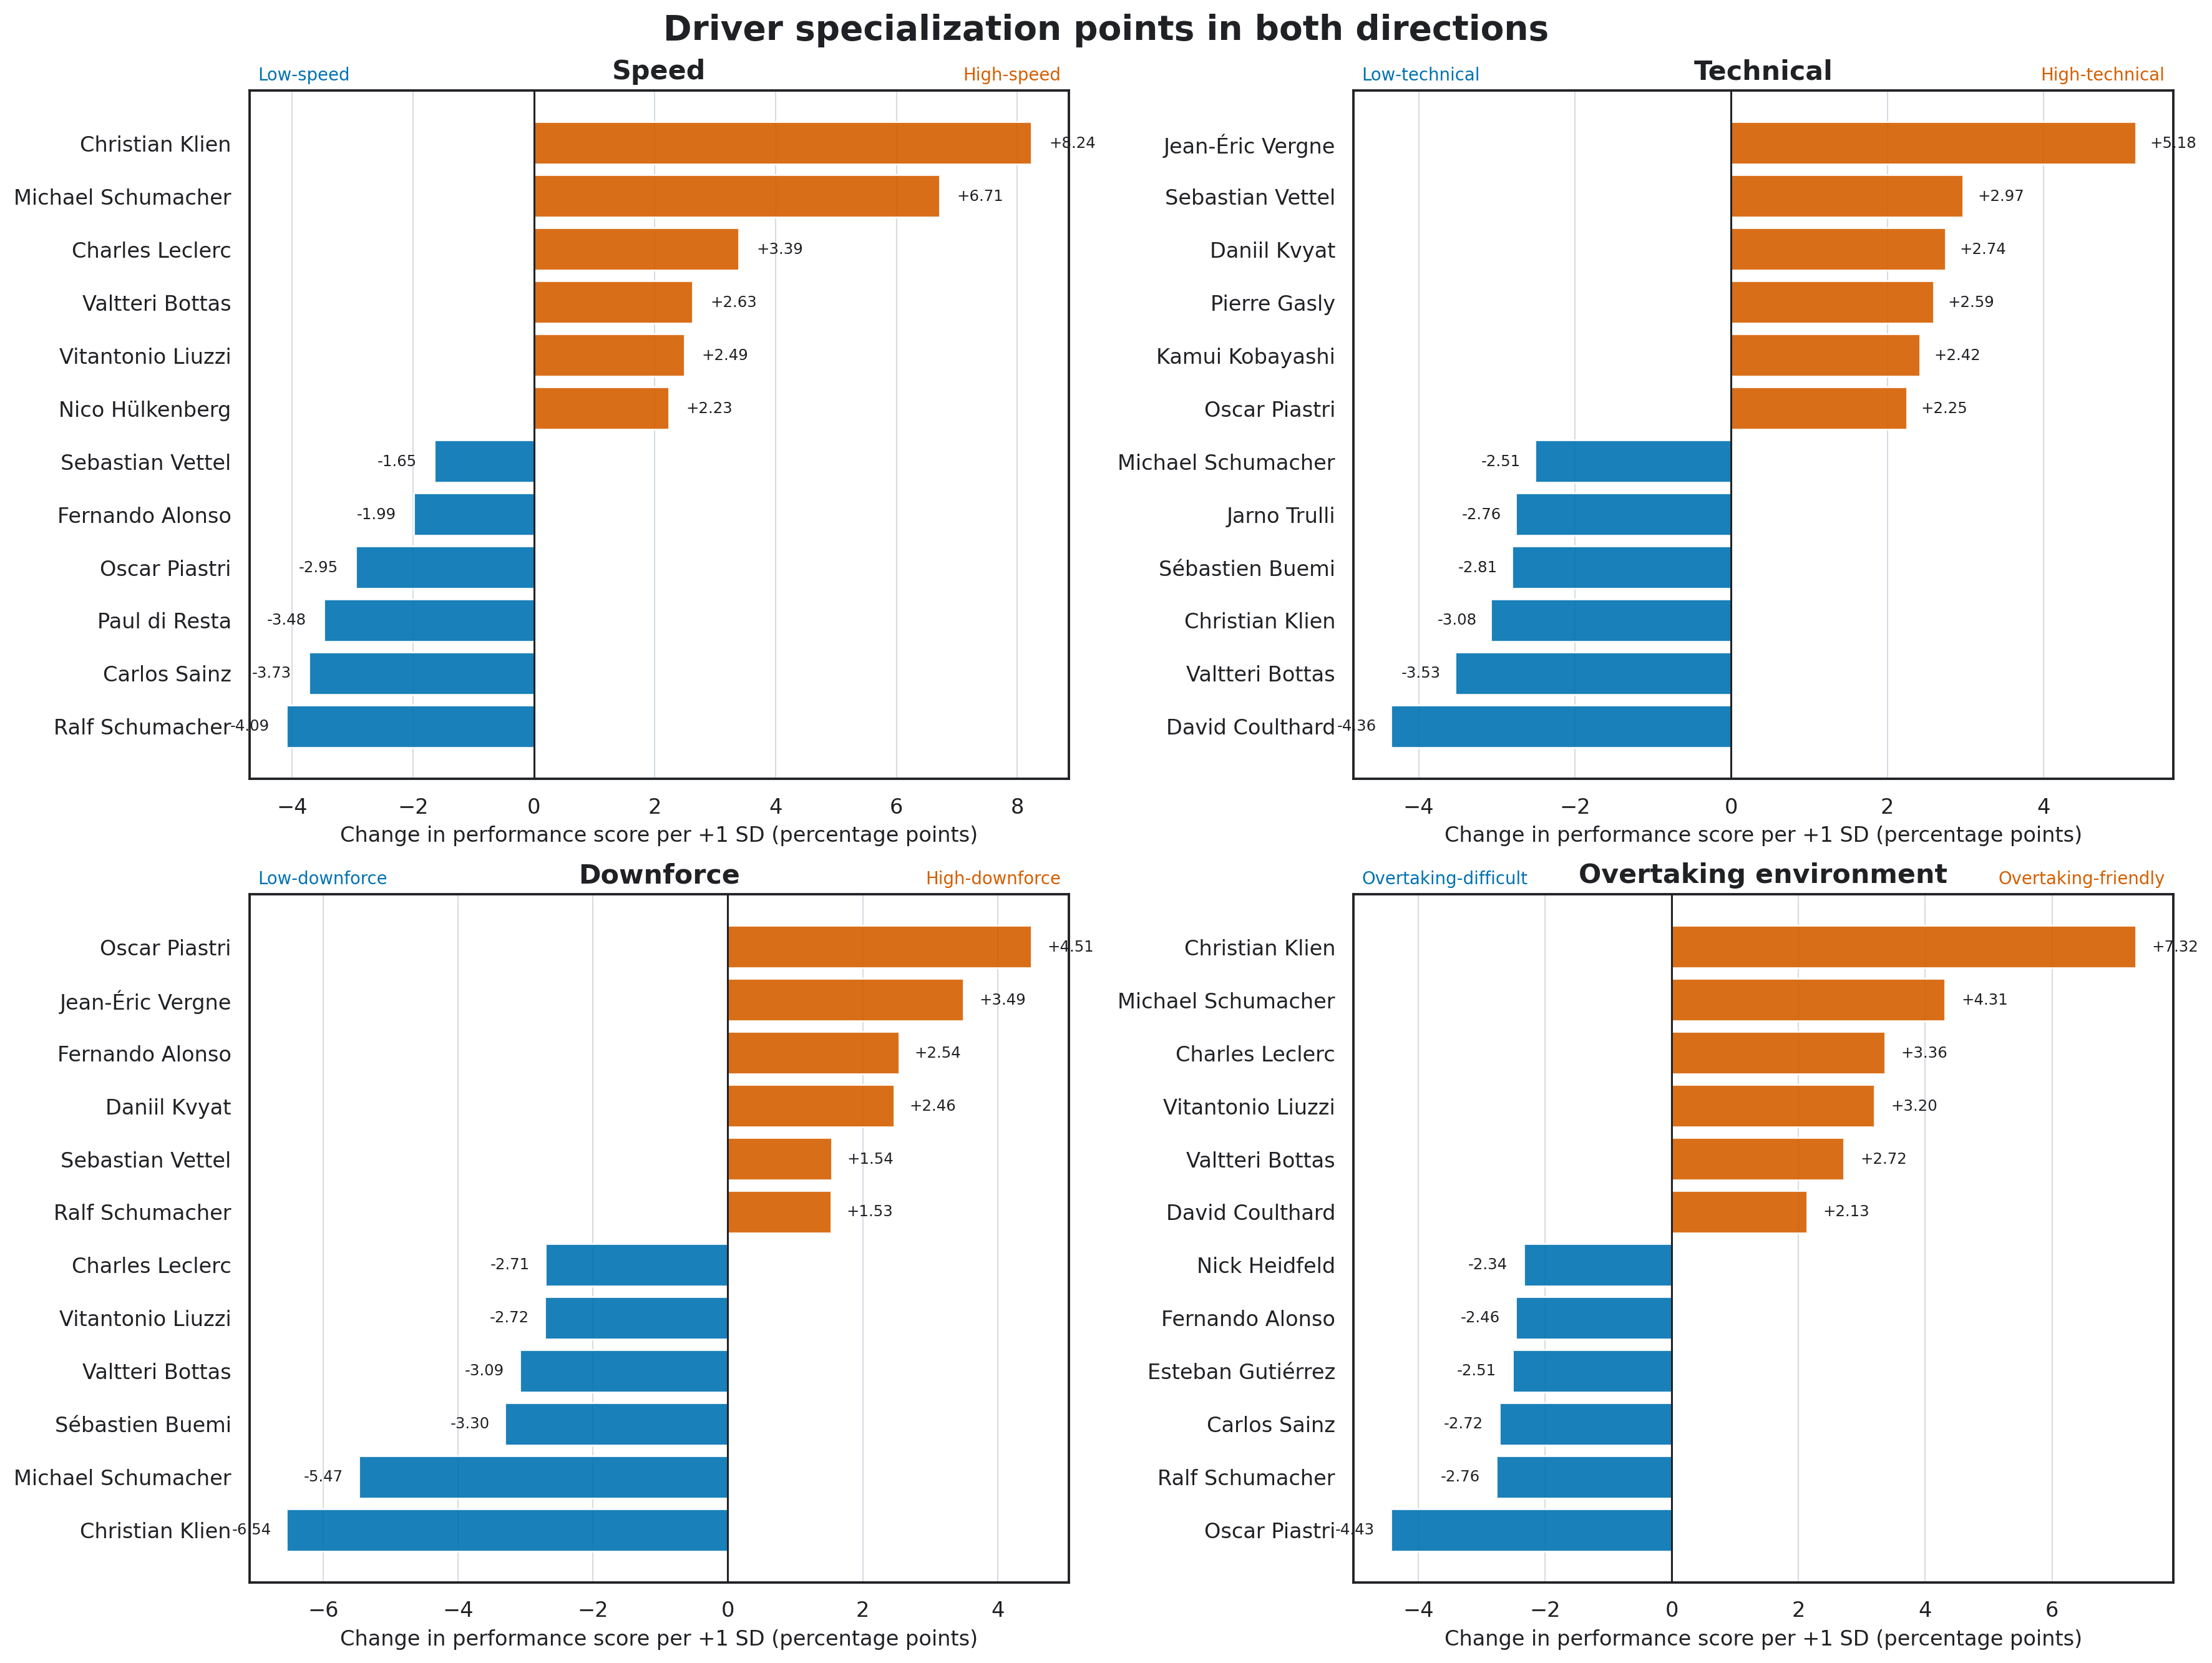

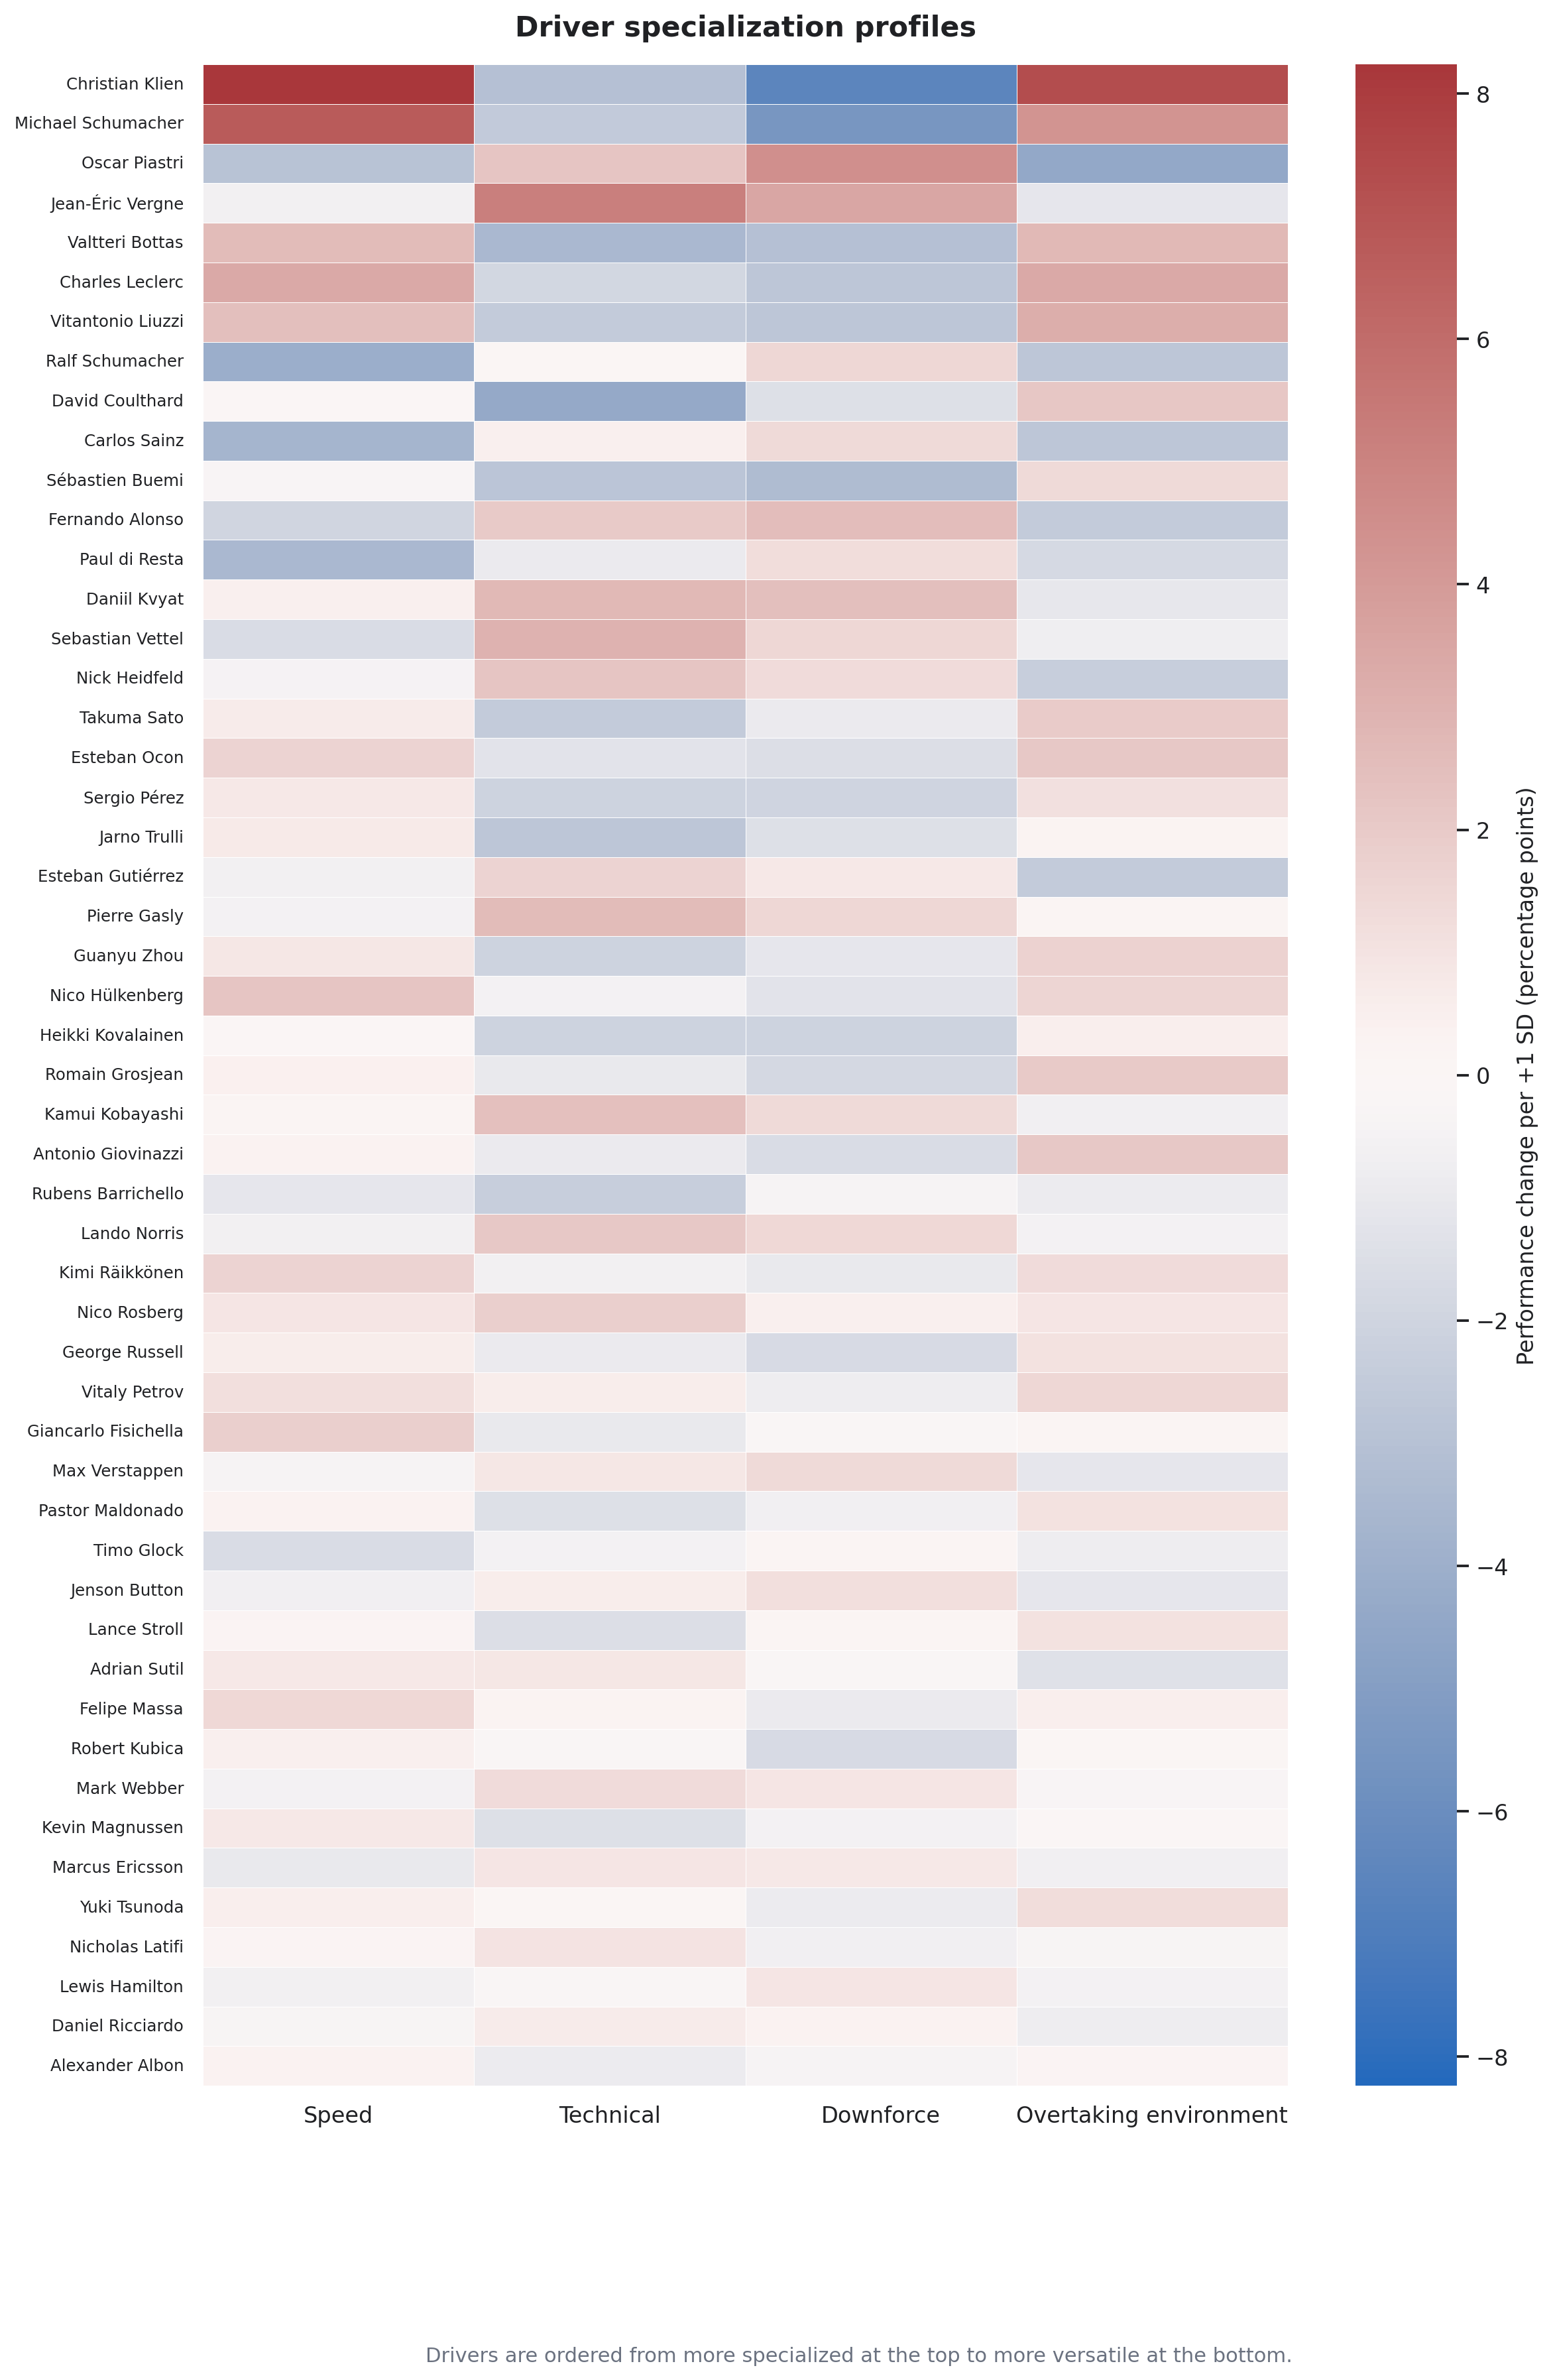

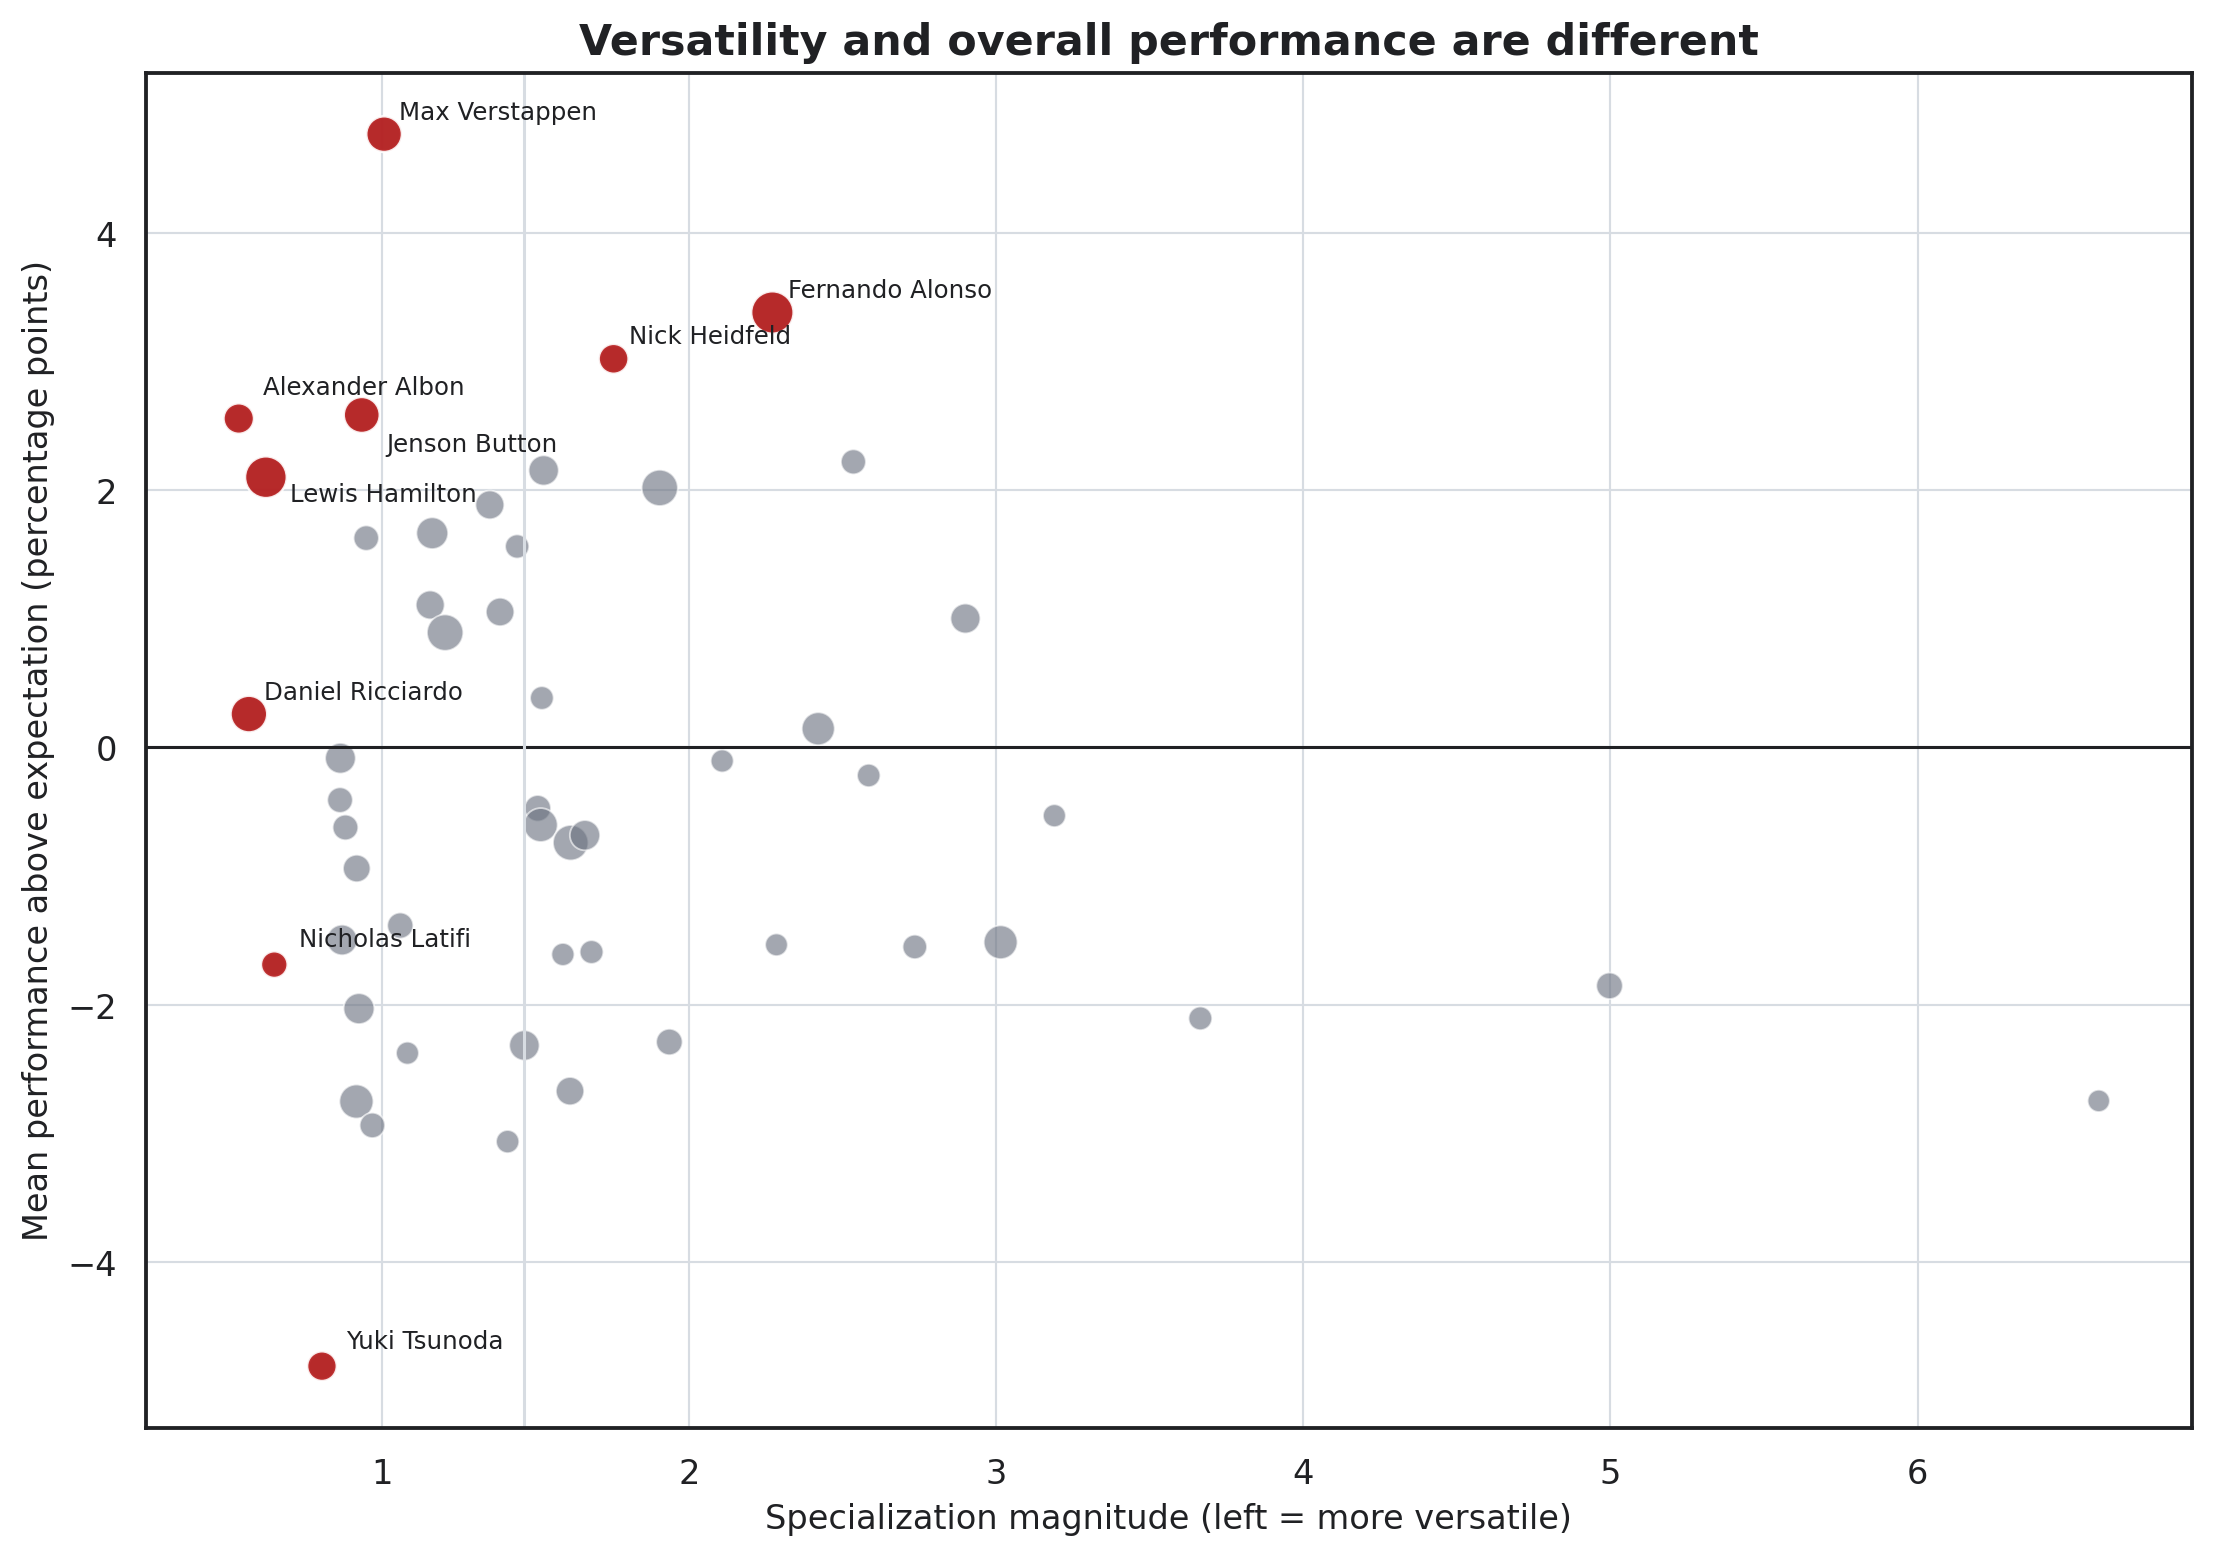

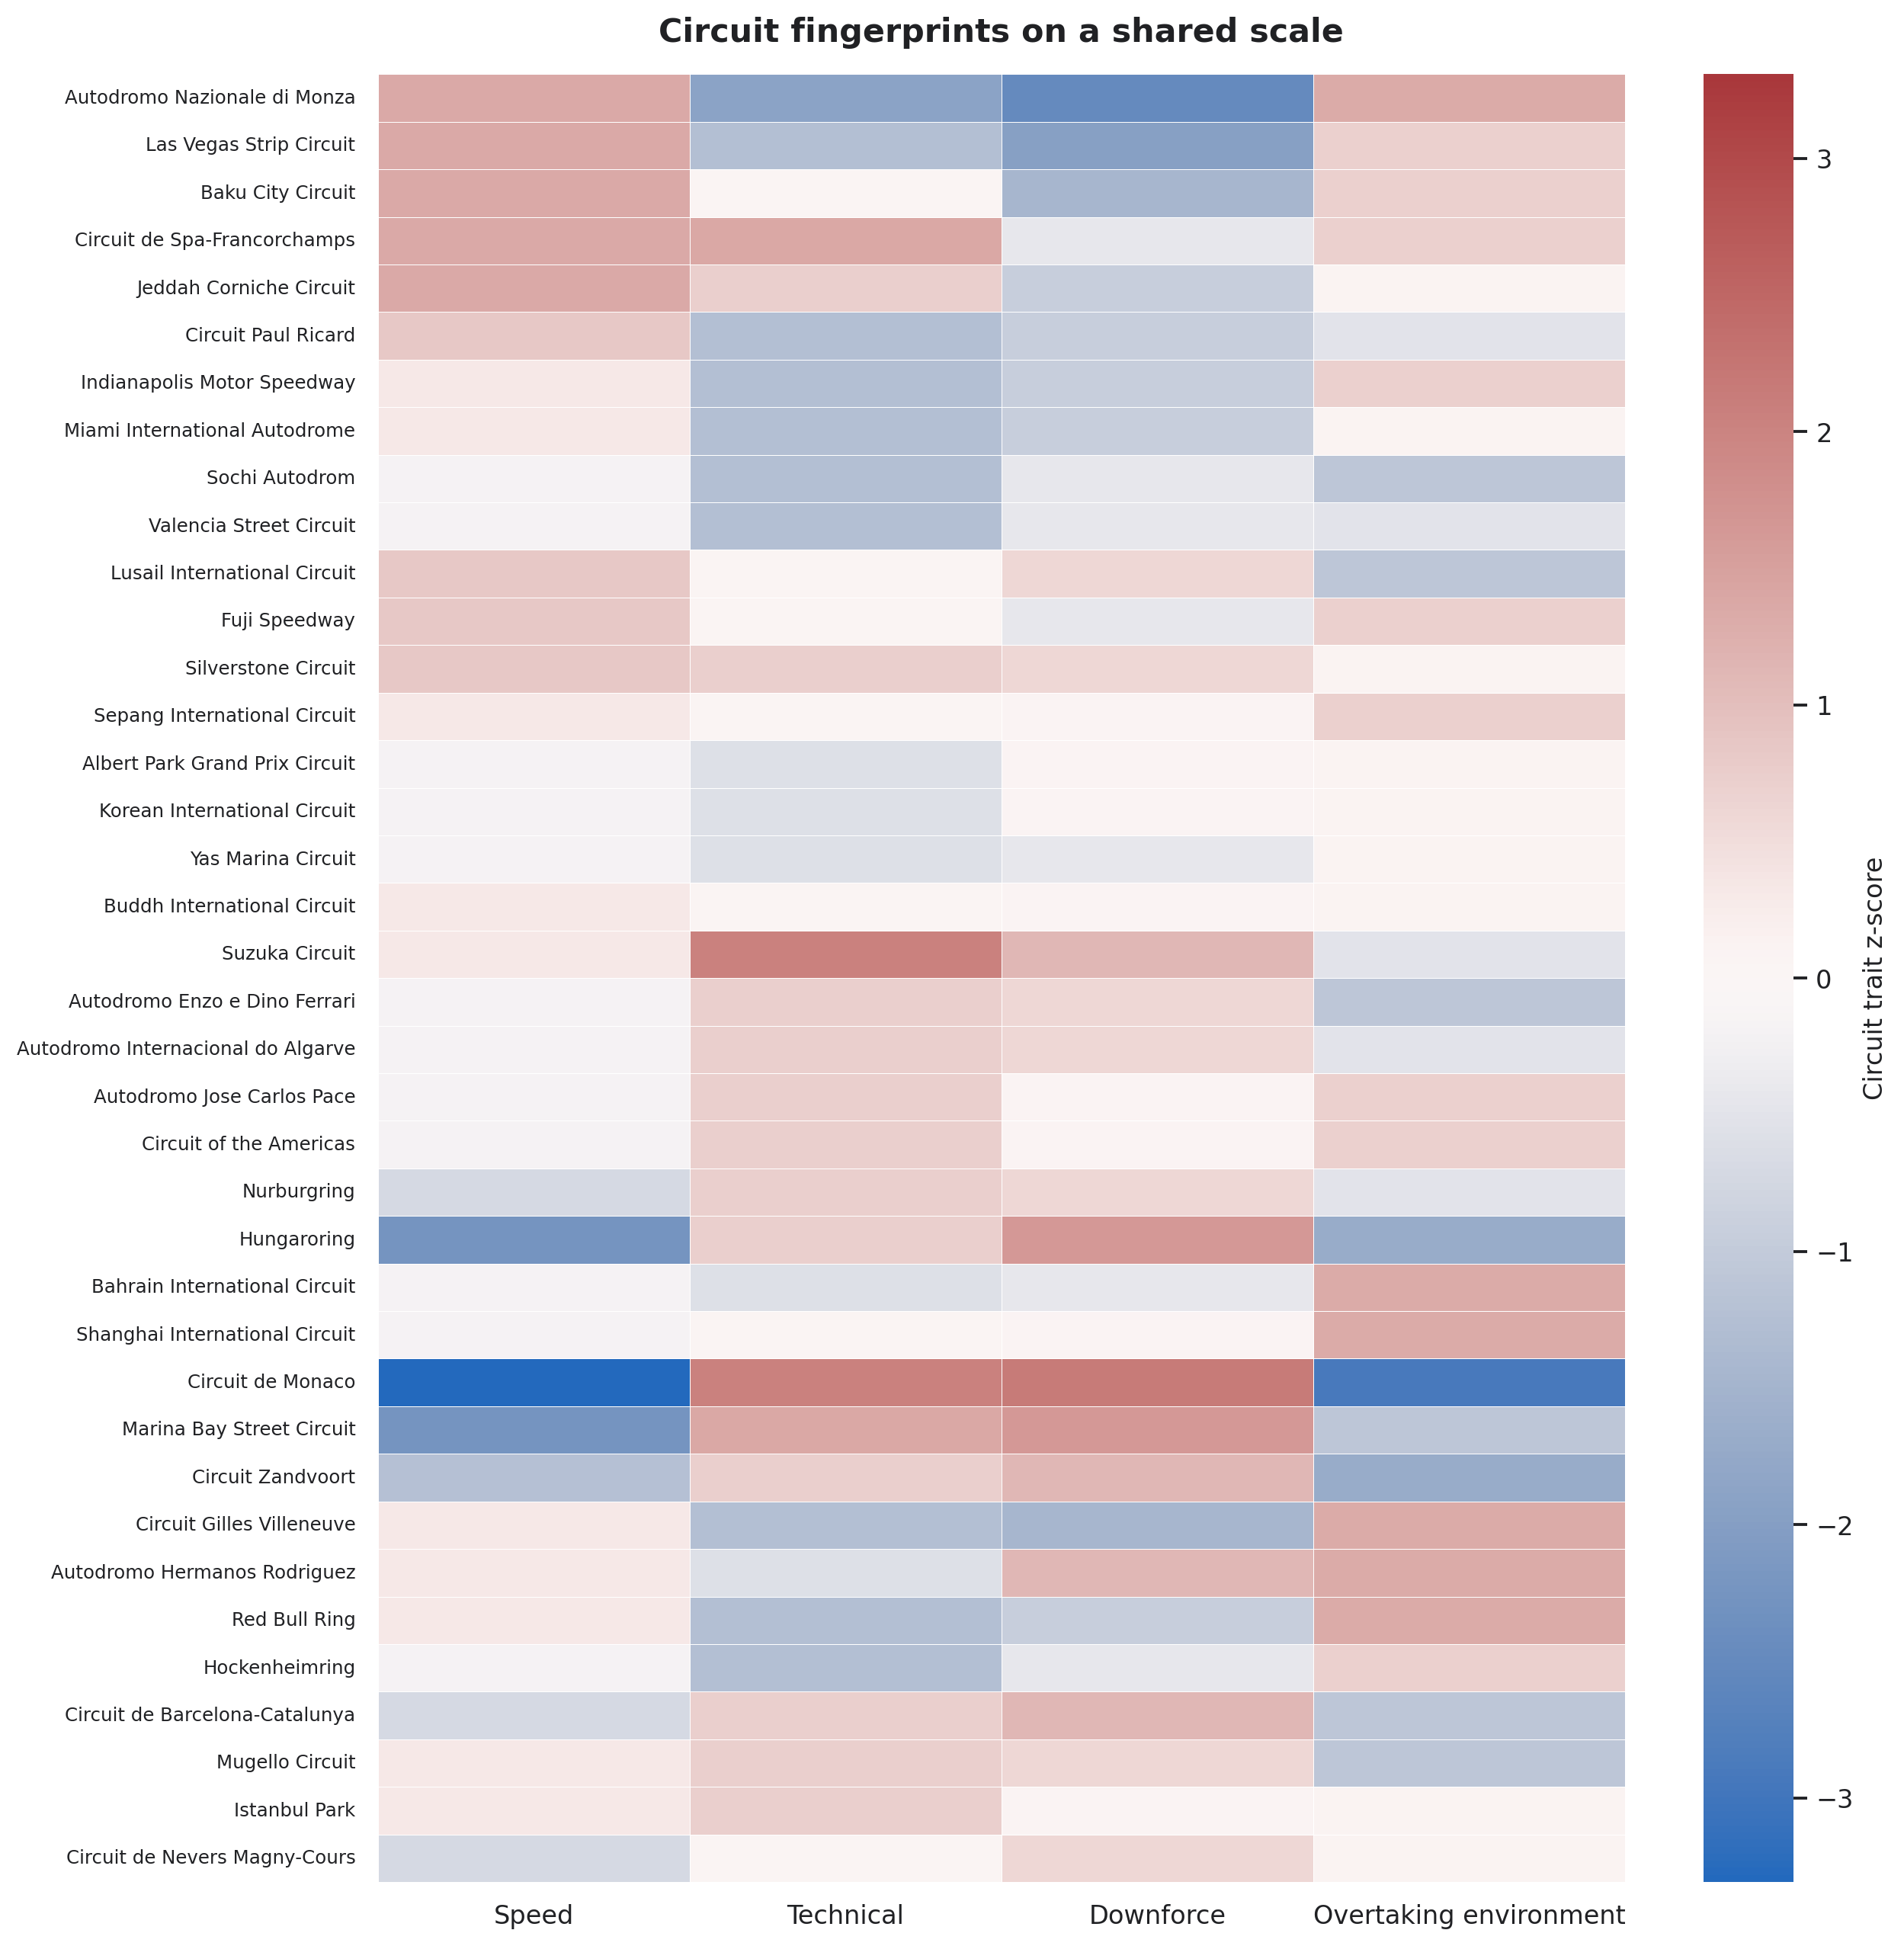

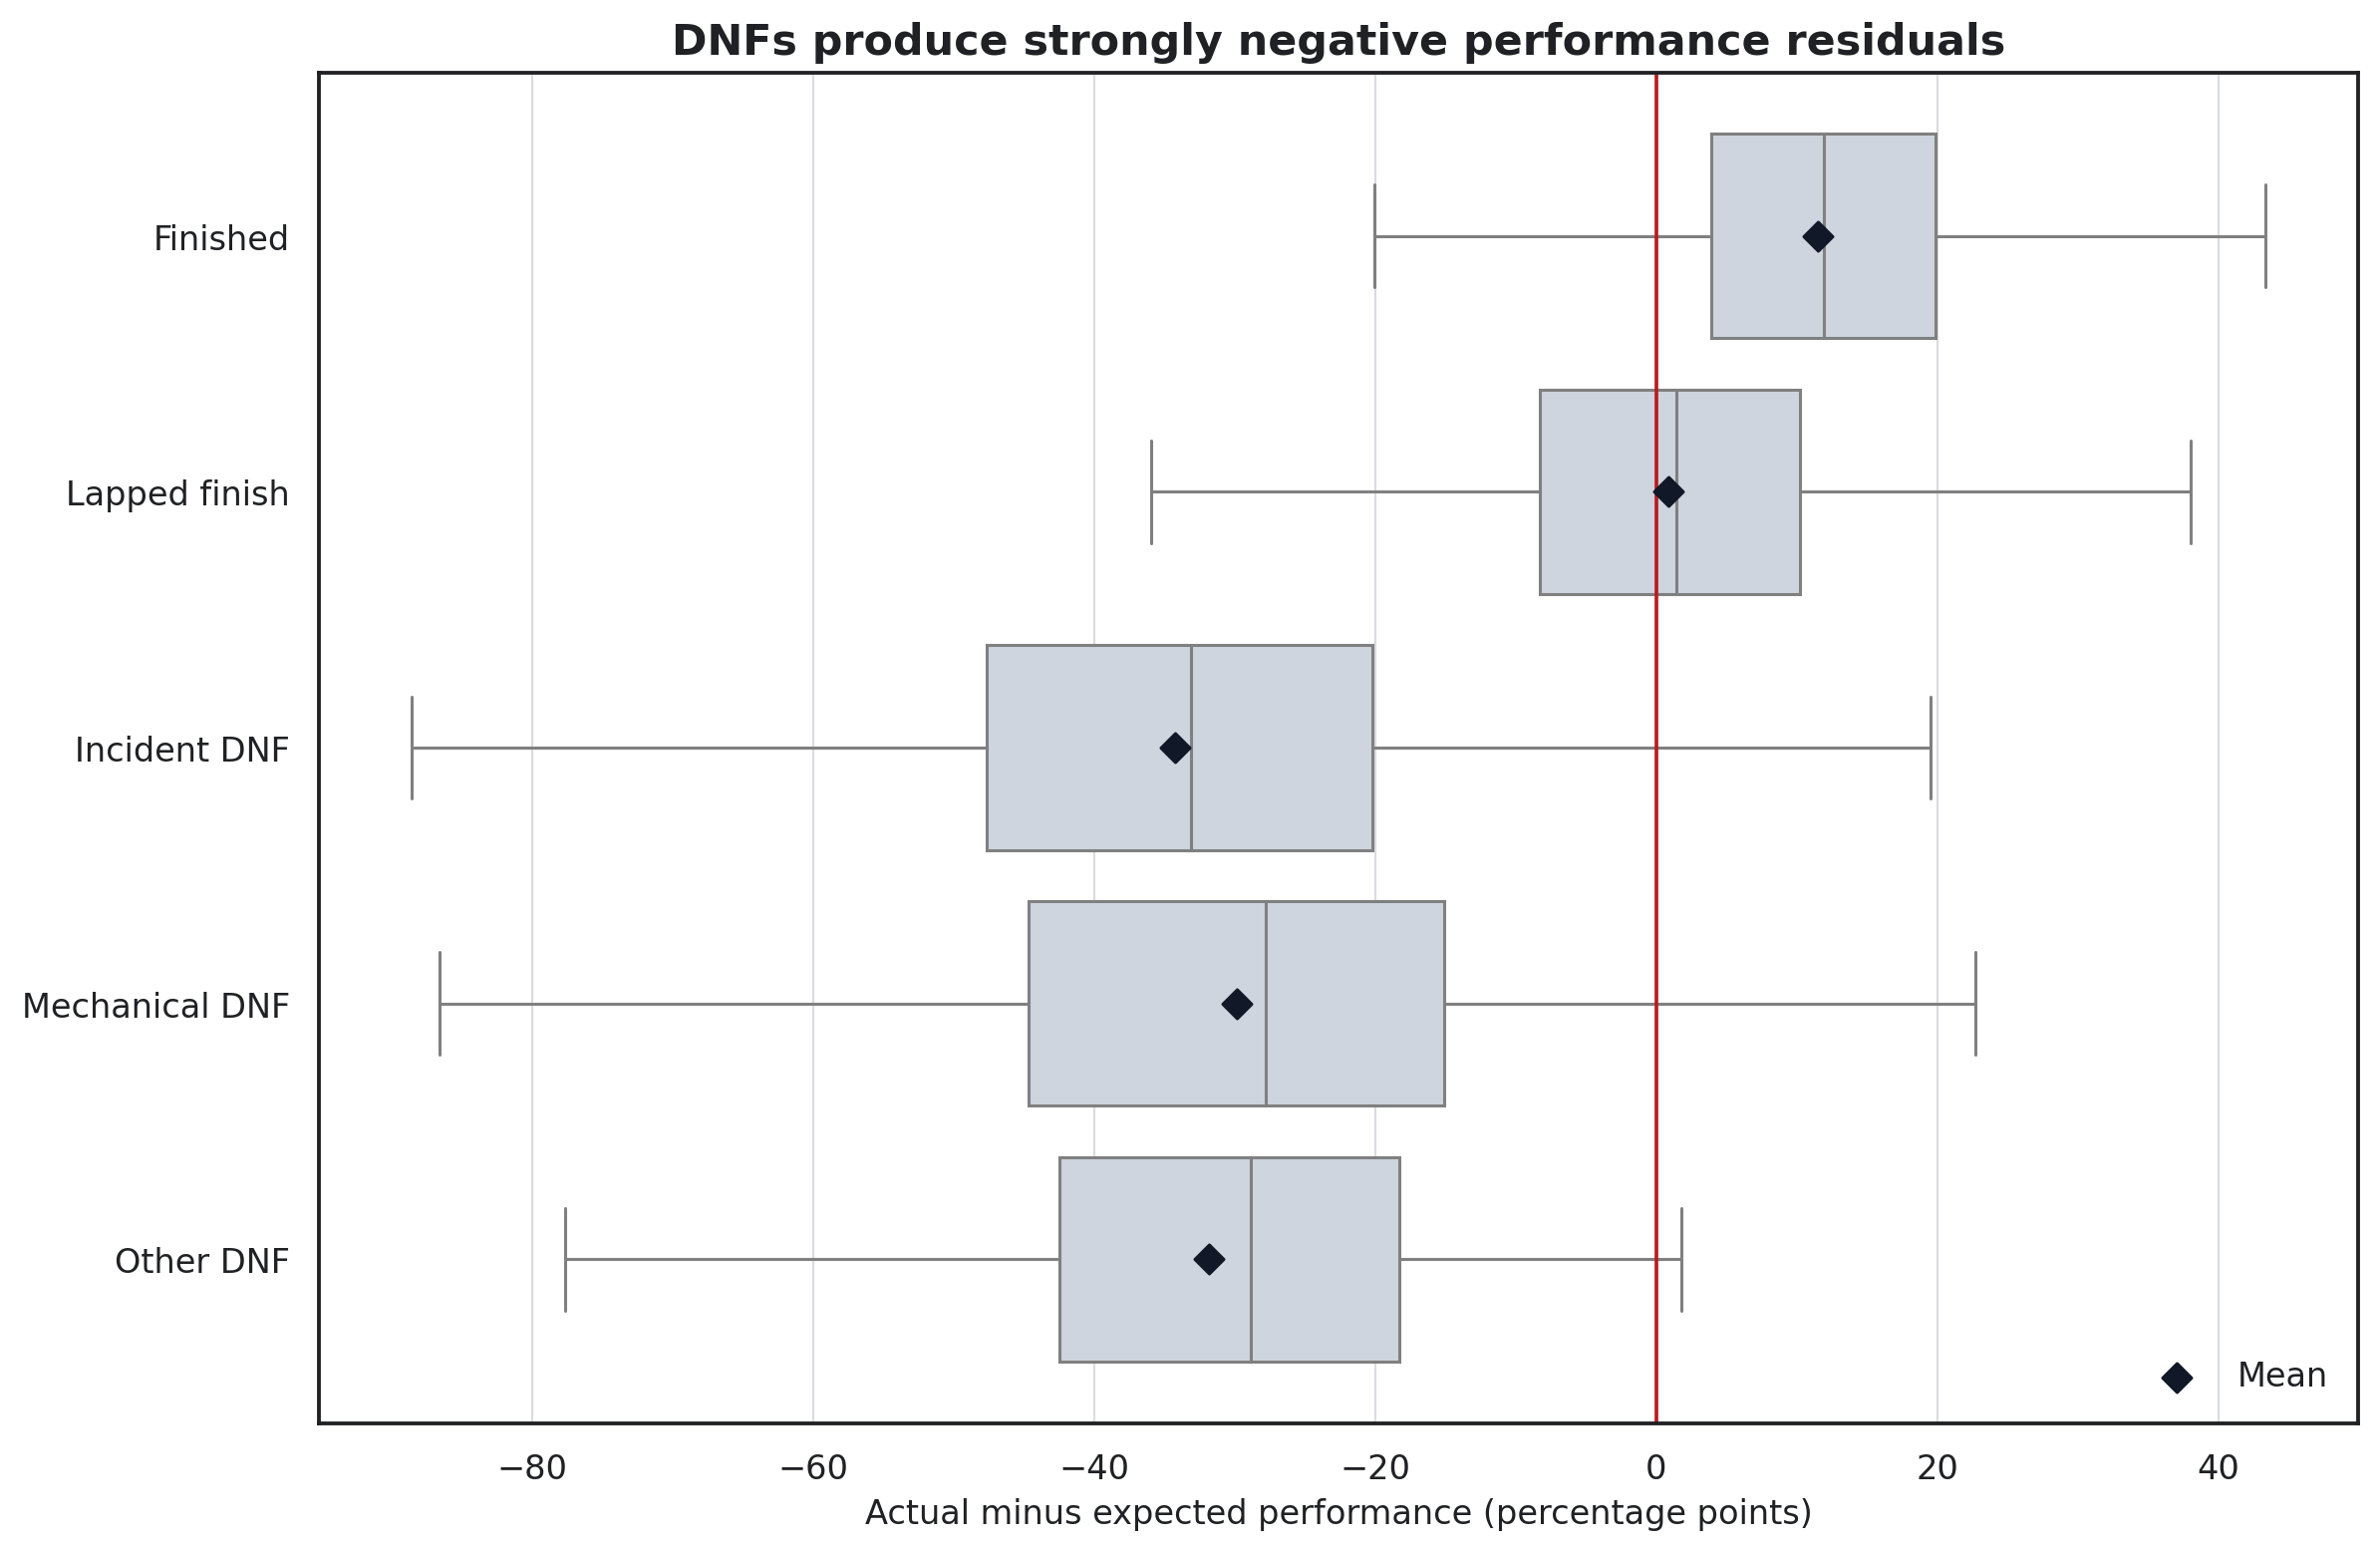

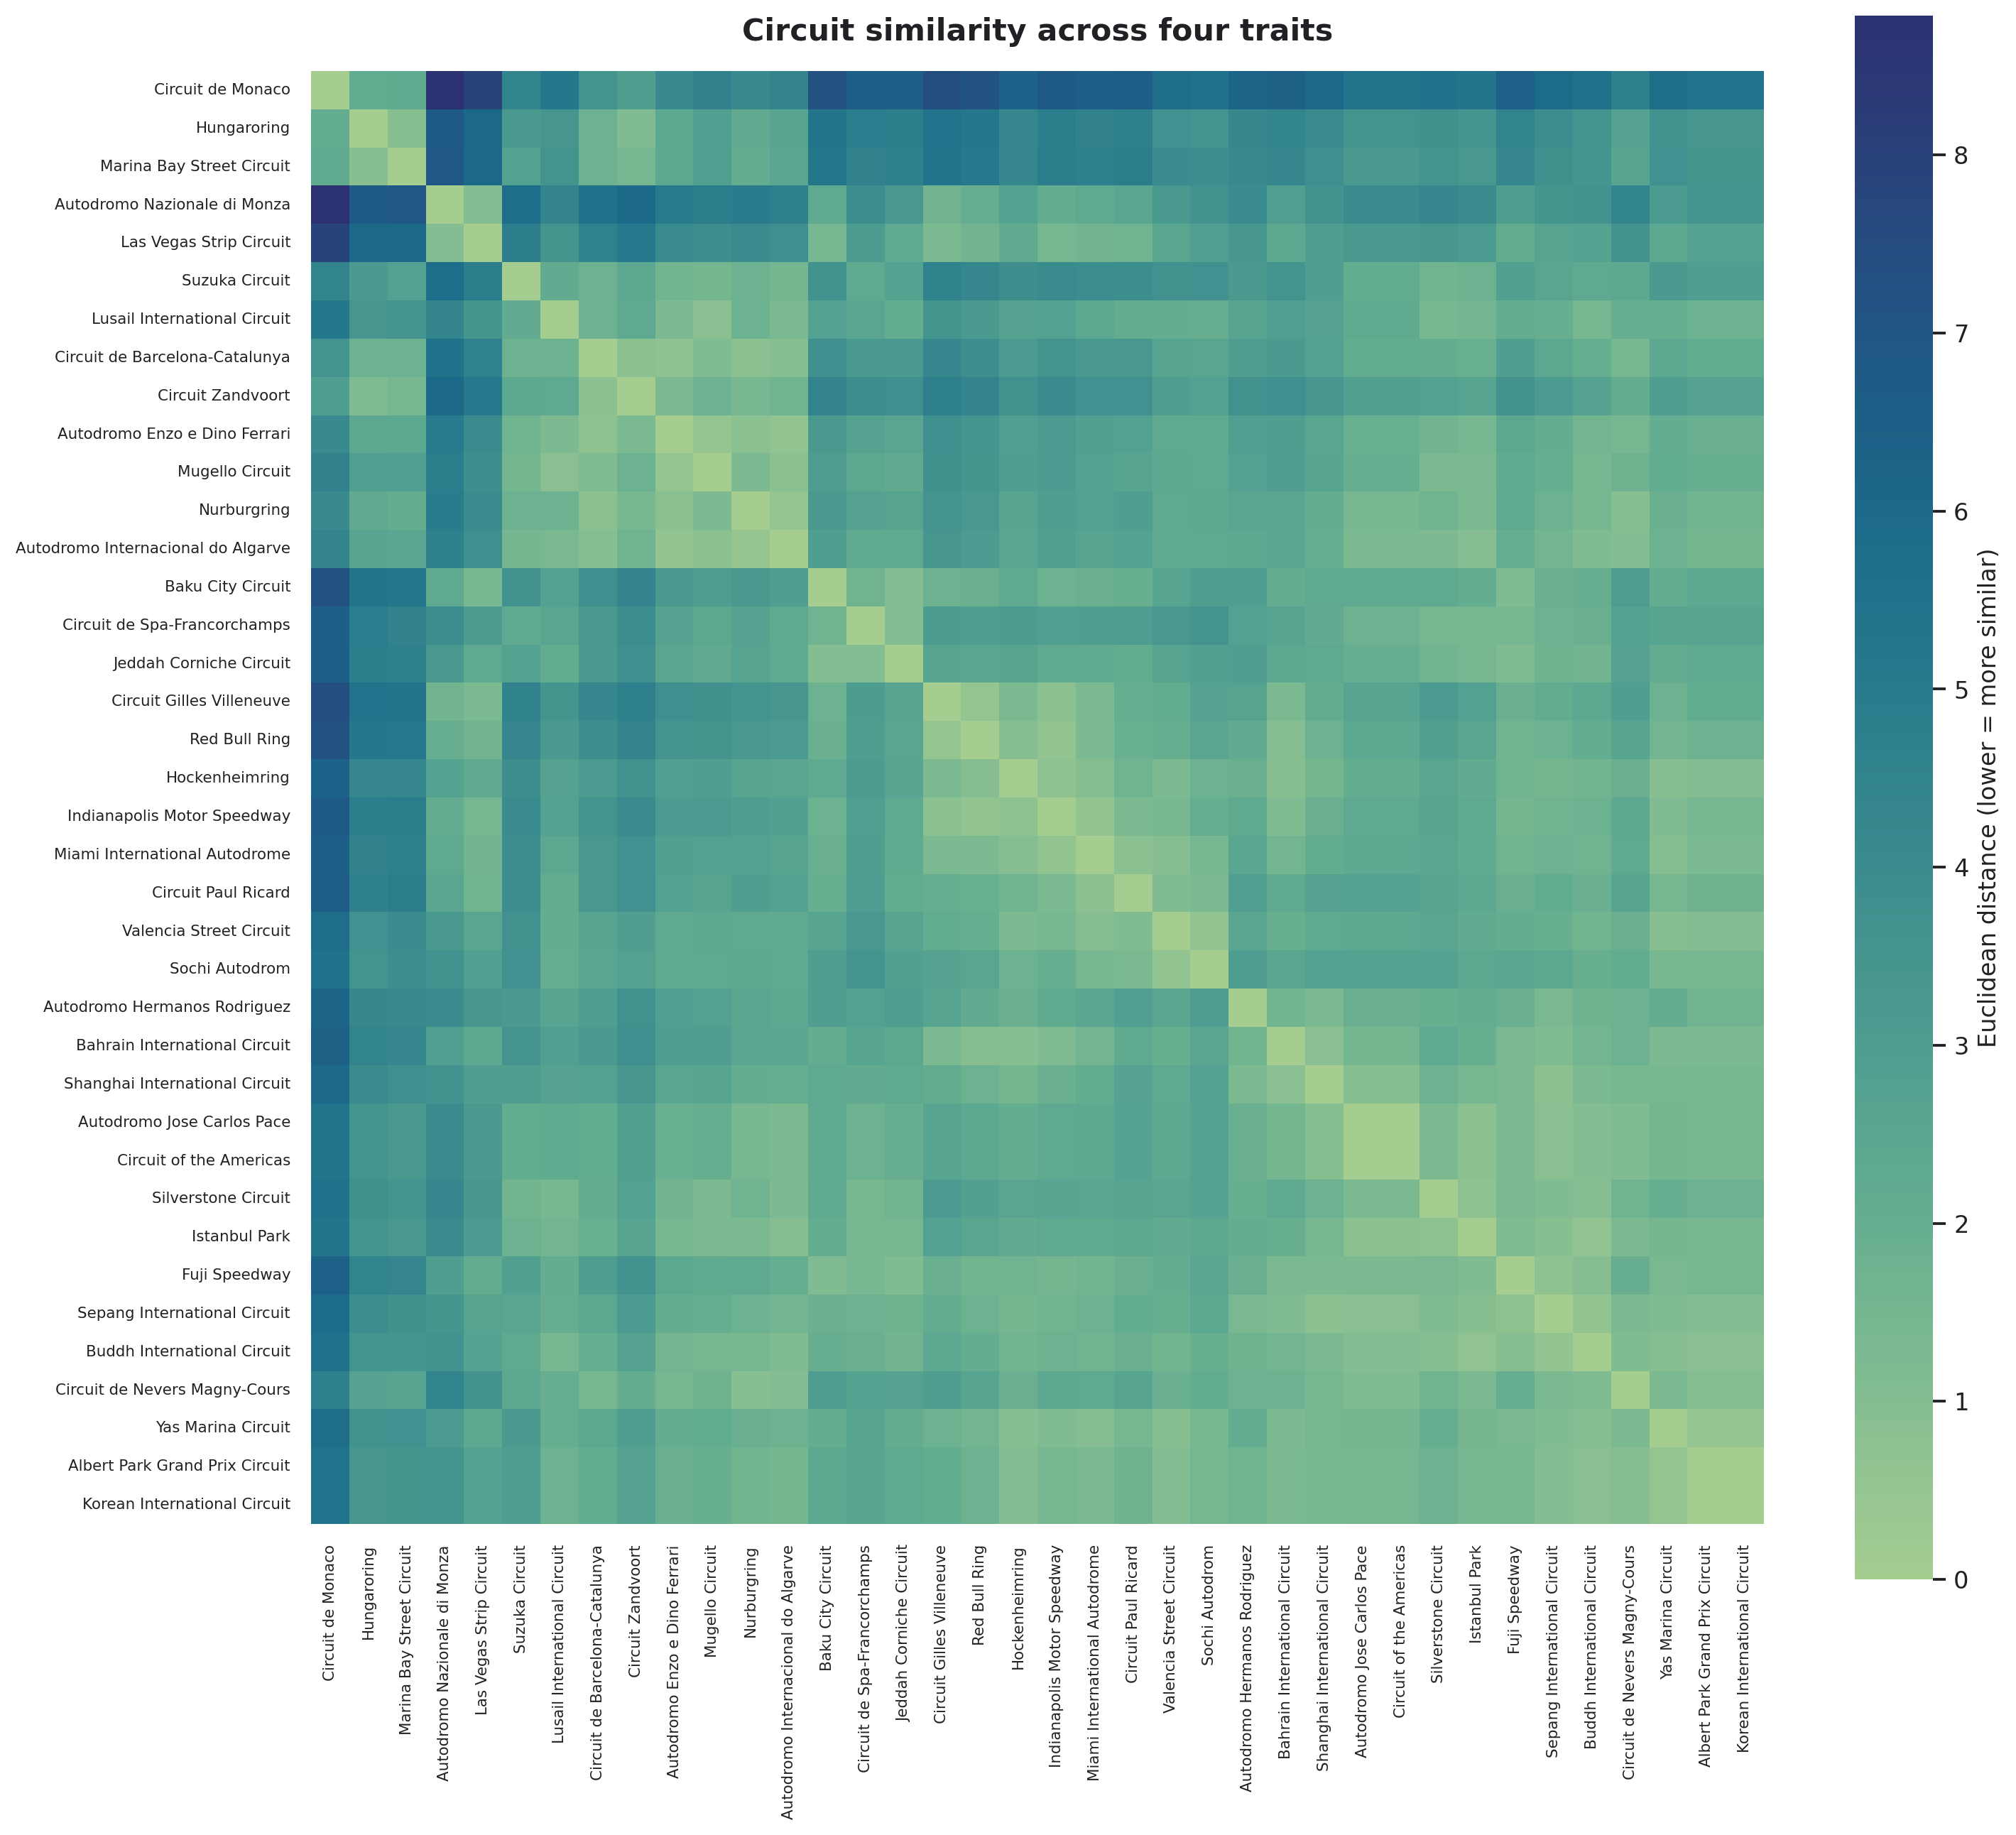

In [6]:
# Figure 1: positive and negative specialists for each trait.
figure, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
for axis, trait in zip(axes.flat, TRAITS):
    chart_data = specialist_selections[trait]
    values = chart_data[f"{trait}_slope_pp"].to_numpy()
    colors = [COLOR_HIGH if value >= 0 else COLOR_LOW for value in values]
    axis.barh(chart_data["driver_full_name"], values, color=colors, alpha=0.9)
    axis.axvline(0, color=COLOR_DARK, linewidth=1)
    annotate_horizontal_bars(axis, values)
    axis.set_title(TRAIT_LABELS[trait])
    axis.set_xlabel("Change in performance score per +1 SD (percentage points)")
    axis.set_ylabel("")
    axis.grid(axis="x", color=COLOR_GRID, linewidth=0.7)
    axis.grid(axis="y", visible=False)
    axis.text(
        0.01, 1.01, LOW_LABELS[trait],
        transform=axis.transAxes, ha="left", va="bottom",
        color=COLOR_LOW, fontsize=9,
    )
    axis.text(
        0.99, 1.01, HIGH_LABELS[trait],
        transform=axis.transAxes, ha="right", va="bottom",
        color=COLOR_HIGH, fontsize=9,
    )
figure.suptitle(
    "Driver specialization points in both directions",
    fontsize=18,
    fontweight="bold",
)
save_figure(figure, FIGURE_PATHS["driver_specialists"])
display_saved_figure(FIGURE_PATHS["driver_specialists"])

# Figure 2: complete driver-trait heatmap.
heatmap_limit = float(np.abs(driver_heatmap_data.to_numpy()).max())
figure, axis = plt.subplots(figsize=(12, 18))
sns.heatmap(
    driver_heatmap_data,
    ax=axis,
    cmap="vlag",
    center=0,
    vmin=-heatmap_limit,
    vmax=heatmap_limit,
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Performance change per +1 SD (percentage points)"},
)
axis.set_title("Driver specialization profiles", pad=14)
axis.set_xlabel("")
axis.set_ylabel("")
axis.tick_params(axis="y", labelsize=8)
figure.text(
    0.5, 0.005,
    "Drivers are ordered from more specialized at the top to more versatile at the bottom.",
    ha="center", fontsize=10, color=COLOR_NEUTRAL,
)
save_figure(figure, FIGURE_PATHS["driver_heatmap"])
display_saved_figure(FIGURE_PATHS["driver_heatmap"])

# Figure 3: versatility must be read alongside overall outperformance.
figure, axis = plt.subplots(figsize=(12, 8))
axis.scatter(
    specialization_plot["specialization_magnitude_pp"],
    specialization_plot["mean_baseline_residual_pp"],
    s=35 + specialization_plot["career_starts"] * 0.35,
    color=COLOR_NEUTRAL,
    alpha=0.62,
    edgecolor="white",
    linewidth=0.6,
)
label_ids = set(
    specialization_plot.nsmallest(5, "specialization_magnitude")["driver_id"]
) | set(
    specialization_plot.nlargest(5, "mean_baseline_residual")["driver_id"]
)
highlight = specialization_plot.loc[
    specialization_plot["driver_id"].isin(label_ids)
]
axis.scatter(
    highlight["specialization_magnitude_pp"],
    highlight["mean_baseline_residual_pp"],
    s=55 + highlight["career_starts"] * 0.35,
    color=COLOR_ACCENT,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.8,
)
label_offsets = {
    "Alexander Albon": (8, 8),
    "Jenson Button": (8, -12),
    "Lewis Hamilton": (8, -8),
    "Nicholas Latifi": (8, 6),
    "Yuki Tsunoda": (8, 6),
}
for row in highlight.itertuples():
    x_offset, y_offset = label_offsets.get(
        row.driver_full_name,
        (5, 5),
    )
    axis.annotate(
        row.driver_full_name,
        (row.specialization_magnitude_pp, row.mean_baseline_residual_pp),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        ha="right" if x_offset < 0 else "left",
        fontsize=8,
    )
axis.axhline(0, color=COLOR_DARK, linewidth=1)
axis.axvline(
    specialization_plot["specialization_magnitude_pp"].median(),
    color=COLOR_GRID,
    linewidth=1,
)
axis.set_title("Versatility and overall performance are different")
axis.set_xlabel("Specialization magnitude (left = more versatile)")
axis.set_ylabel("Mean performance above expectation (percentage points)")
axis.grid(color=COLOR_GRID, linewidth=0.7)
save_figure(figure, FIGURE_PATHS["versatility_scatter"])
display_saved_figure(FIGURE_PATHS["versatility_scatter"])

# Figure 4: circuit fingerprints on the shared standardized scale.
fingerprint_limit = float(
    np.abs(circuit_fingerprint_data.to_numpy()).max()
)
figure, axis = plt.subplots(figsize=(12, 14))
sns.heatmap(
    circuit_fingerprint_data,
    ax=axis,
    cmap="vlag",
    center=0,
    vmin=-fingerprint_limit,
    vmax=fingerprint_limit,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Circuit trait z-score"},
)
axis.set_title("Circuit fingerprints on a shared scale", pad=14)
axis.set_xlabel("")
axis.set_ylabel("")
axis.tick_params(axis="y", labelsize=8)
save_figure(figure, FIGURE_PATHS["circuit_fingerprints"])
display_saved_figure(FIGURE_PATHS["circuit_fingerprints"])

# Figure 5: residual distributions by observed outcome.
status_plot = track_plot.loc[
    track_plot["finish_status_group"].isin(status_order)
].copy()
status_plot["finish_status_label"] = status_plot[
    "finish_status_group"
].map(status_labels)
label_order = [status_labels[status] for status in status_order]
figure, axis = plt.subplots(figsize=(12, 8))
sns.boxplot(
    data=status_plot,
    y="finish_status_label",
    x="baseline_residual_pp",
    order=label_order,
    showfliers=False,
    color="#CBD5E1",
    linewidth=1,
    ax=axis,
)
status_means = (
    status_plot.groupby("finish_status_label")["baseline_residual_pp"]
    .mean().reindex(label_order)
)
axis.scatter(
    status_means.to_numpy(),
    np.arange(len(status_means)),
    color=COLOR_MEAN,
    marker="D",
    s=45,
    zorder=4,
    label="Mean",
)
axis.axvline(0, color=COLOR_ACCENT, linewidth=1.2)
axis.set_title("DNFs produce strongly negative performance residuals")
axis.set_xlabel("Actual minus expected performance (percentage points)")
axis.set_ylabel("")
axis.legend(frameon=False, loc="lower right")
axis.grid(axis="x", color=COLOR_GRID, linewidth=0.7)
axis.grid(axis="y", visible=False)
save_figure(figure, FIGURE_PATHS["residual_status"])
display_saved_figure(FIGURE_PATHS["residual_status"])

# Figure 6: Euclidean similarity across the four standardized traits.
distance_limit = float(circuit_distance_matrix.to_numpy().max())
figure, axis = plt.subplots(figsize=(15, 13))
sns.heatmap(
    circuit_distance_matrix,
    ax=axis,
    cmap="crest",
    vmin=0,
    vmax=distance_limit,
    square=True,
    cbar_kws={"label": "Euclidean distance (lower = more similar)"},
)
axis.set_title("Circuit similarity across four traits", pad=14)
axis.set_xlabel("")
axis.set_ylabel("")
axis.tick_params(axis="x", labelrotation=90, labelsize=7)
axis.tick_params(axis="y", labelrotation=0, labelsize=7)
save_figure(figure, FIGURE_PATHS["circuit_similarity"])
display_saved_figure(FIGURE_PATHS["circuit_similarity"])

## Validation

In [7]:
missing_specialization_values = specialization[
    [
        "driver_id", "career_starts", "mean_baseline_residual",
        "specialization_magnitude", *SLOPE_COLUMNS,
    ]
].isna().sum().to_dict()
missing_circuit_values = circuit_features[
    ["circuit_id", "circuit_name", *ZSCORE_COLUMNS]
].isna().sum().to_dict()
figure_keys = set(FIGURE_PATHS)
expected_figure_keys = {
    "driver_specialists", "driver_heatmap", "versatility_scatter",
    "circuit_fingerprints", "residual_status", "circuit_similarity",
}

checks = [
    report_check(
        "expected eligible-driver population",
        len(specialization) == 51
        and specialization["driver_id"].nunique() == 51,
        {
            "rows": len(specialization),
            "drivers": specialization["driver_id"].nunique(),
        },
    ),
    report_check(
        "expected circuit population",
        len(circuit_features) == 38
        and circuit_features["circuit_id"].nunique() == 38,
        {
            "rows": len(circuit_features),
            "circuits": circuit_features["circuit_id"].nunique(),
        },
    ),
    report_check(
        "specialization chart inputs are complete",
        all(value == 0 for value in missing_specialization_values.values()),
        missing_specialization_values,
    ),
    report_check(
        "circuit chart inputs are complete",
        all(value == 0 for value in missing_circuit_values.values()),
        missing_circuit_values,
    ),
    report_check(
        "each trait includes both directional specialist groups",
        all(
            (
                specialist_selections[trait][f"{trait}_slope_pp"].lt(0).any()
                and specialist_selections[trait][f"{trait}_slope_pp"].gt(0).any()
            )
            for trait in TRAITS
        ),
        {
            trait: {
                "negative": int(
                    specialist_selections[trait][f"{trait}_slope_pp"].lt(0).sum()
                ),
                "positive": int(
                    specialist_selections[trait][f"{trait}_slope_pp"].gt(0).sum()
                ),
            }
            for trait in TRAITS
        },
    ),
    report_check(
        "heatmap uses one shared raw slope scale",
        driver_heatmap_data.shape == (51, 4),
        {
            "rows": driver_heatmap_data.shape[0],
            "traits": driver_heatmap_data.shape[1],
        },
    ),
    report_check(
        "versatility and overall performance remain separate",
        not specialization[
            ["specialization_magnitude", "mean_baseline_residual"]
        ].duplicated().all(),
        {
            "correlation": float(
                specialization["specialization_magnitude"].corr(
                    specialization["mean_baseline_residual"]
                )
            )
        },
    ),
    report_check(
        "residual chart includes all modeled finish categories",
        set(status_order)
        <= set(track_plot["finish_status_group"].dropna().unique()),
        sorted(
            set(status_order)
            - set(track_plot["finish_status_group"].dropna().unique())
        ),
    ),
    report_check(
        "exact planned figure set",
        figure_keys == expected_figure_keys and len(FIGURE_PATHS) == 6,
        sorted(figure_keys),
    ),
]

validation_report = {
    "notebook": "05_visualizations",
    "status": "PASS" if all(check["passed"] for check in checks) else "FAIL",
    "checks": checks,
}
display(pd.DataFrame(checks))
if validation_report["status"] != "PASS":
    failed = [check for check in checks if not check["passed"]]
    raise AssertionError(f"Validation failed: {failed}")
print("PASS")

,check,passed,details
0,expected eligible-driver population,True,"{'rows': 51, 'drivers': 51}"
1,expected circuit population,True,"{'rows': 38, 'circuits': 38}"
2,specialization chart inputs are complete,True,"{'driver_id': 0, 'career_starts': 0, 'mean_bas..."
3,circuit chart inputs are complete,True,"{'circuit_id': 0, 'circuit_name': 0, 'speed_zs..."
4,each trait includes both directional specialis...,True,"{'speed': {'negative': 6, 'positive': 6}, 'tec..."
5,heatmap uses one shared raw slope scale,True,"{'rows': 51, 'traits': 4}"
6,versatility and overall performance remain sep...,True,{'correlation': -0.1816976569801459}
7,residual chart includes all modeled finish cat...,True,[]
8,exact planned figure set,True,"[circuit_fingerprints, circuit_similarity, dri..."


PASS


## Supercheck

In [8]:
superchecks = []
for name, path in FIGURE_PATHS.items():
    exists = path.exists()
    size_bytes = path.stat().st_size if exists else 0
    if exists:
        with PILImage.open(path) as image:
            image_format = image.format
            width, height = image.size
            image.verify()
    else:
        image_format = None
        width, height = 0, 0
    passed = (
        exists
        and size_bytes > 10_000
        and image_format == "PNG"
        and width >= MIN_IMAGE_WIDTH
        and height >= MIN_IMAGE_HEIGHT
    )
    superchecks.append(
        report_check(
            f"{name} PNG integrity",
            passed,
            {
                "path": str(path),
                "bytes": size_bytes,
                "width": width,
                "height": height,
                "format": image_format,
            },
        )
    )

validation_report["superchecks"] = superchecks
validation_report["status"] = (
    "PASS" if all(check["passed"] for check in checks + superchecks) else "FAIL"
)
serializable_report = json.loads(json.dumps(validation_report, default=str))
temporary_report_path = VALIDATION_REPORT_PATH.with_suffix(".json.tmp")
with temporary_report_path.open("w", encoding="utf-8") as handle:
    json.dump(serializable_report, handle, indent=2)
temporary_report_path.replace(VALIDATION_REPORT_PATH)

saved_report = json.loads(VALIDATION_REPORT_PATH.read_text(encoding="utf-8"))
report_checks = [
    report_check(
        "validation report file exists",
        VALIDATION_REPORT_PATH.exists(),
        str(VALIDATION_REPORT_PATH),
    ),
    report_check(
        "saved validation report equals memory",
        saved_report == serializable_report,
        None,
    ),
]
display(pd.DataFrame(superchecks + report_checks))
if validation_report["status"] != "PASS" or not all(
    check["passed"] for check in report_checks
):
    raise AssertionError("Supercheck failed")
print("PASS")

,check,passed,details
0,driver_specialists PNG integrity,True,{'path': '
1,driver_heatmap PNG integrity,True,{'path': '
2,versatility_scatter PNG integrity,True,{'path': '
3,circuit_fingerprints PNG integrity,True,{'path': '
4,residual_status PNG integrity,True,{'path': '
5,circuit_similarity PNG integrity,True,{'path': '
6,validation report file exists,True,
7,saved validation report equals memory,True,None


PASS
